In [1]:
import os
from multiprocess import set_start_method
set_start_method("spawn")
import torch
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)


In [2]:

import torch
from scipy import stats
import numpy as np

import numpy as np
from scipy import stats
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed


In [3]:
from influence_estimation.data_inf import DataInfEstimator
from influence_estimation.less_inf import LESSEstimator
from datasets import load_dataset

train_dataset_name = "allenai/tulu-v2-sft-mixture"
test_dataset_name = "allenai/tulu-v2-sft-mixture"

train_dataset_split = "train[0:2000]"
test_dataset_split = "train[0:100]"

train_dataset = load_dataset(train_dataset_name, split="train[0:2000]")
train_dataset = train_dataset.map(
    lambda example, idx: {"indices": idx},
    with_indices=True, num_proc=10
)





test_dataset = load_dataset(test_dataset_name, split="train[0:100]")
test_dataset = test_dataset.map(
    lambda example, idx: {"indices": idx},
    with_indices=True, num_proc=10
)


[INFO] PyTorch version 2.7.0+cu126 available.


In [4]:
train_dataset

Dataset({
    features: ['dataset', 'id', 'messages', 'indices'],
    num_rows: 2000
})

In [5]:
from influence_estimation.data_inf import DataInfEstimator
from influence_estimation.less_inf import LESSEstimator

In [6]:
estimators = [
        LESSEstimator("./models/pythia-31m_tulu-v2-sft-mixture_train", train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split),
        LESSEstimator("./models/pythia-31m_tulu-v2-sft-mixture_train", train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split,normalize=False),
        DataInfEstimator("./models/pythia-31m_tulu-v2-sft-mixture_train", train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split)
    
    ]

In [7]:
# estimators = [
#     # LESSEstimator(base_model_path, adapter_path, train_dataset, test_dataset,fast_implementation=False),
#     # LESSEstimator(base_model_path, adapter_path, train_dataset, test_dataset,fast_implementation=True),
#     LESSEstimator("./models/OLMo-2-0425-1B_tulu-v2-sft-mixture_train", train_dataset, test_dataset),
#     LESSEstimator("./models/OLMo-2-0425-1B_tulu-v2-sft-mixture_train", train_dataset, test_dataset, normalize=False),
#     DataInfEstimator("./models/OLMo-2-0425-1B_tulu-v2-sft-mixture_train",train_dataset, test_dataset)
   
# ]

In [8]:
import logging
logging.getLogger().setLevel(logging.WARNING)
from itertools import cycle


In [9]:
%%writefile evaluation_worker.py
import torch
import itertools
from tqdm import tqdm
import os
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed
CACHE_DIR = "./cache/score/"

def process_single(estimator, explanation, train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split, methods, device_id):
    device = f"cuda:{device_id}"

    test_grad = estimator.get_gradient(test_dataset, os.path.basename(test_dataset_name), test_dataset_split, explanation.dataset_idx).to(device)

    train_grads_cpu = torch.stack(
        [estimator.get_gradient(train_dataset, os.path.basename(train_dataset_name), train_dataset_split, i).cpu() for i in explanation.documents]
    )
    mean = train_grads_cpu.mean(dim=0, keepdim=True)
    centered = train_grads_cpu - mean
    U, S, Vh = torch.linalg.svd(centered, full_matrices=False)
    klt_basis = Vh.T.to(device)
    train_grads = train_grads_cpu.to(device)

    # KLT
    coeffs = klt_basis.T @ test_grad.view(-1)
    x_hat = klt_basis @ coeffs
    var_pred_error = torch.var(test_grad - x_hat, correction=0)
    pred_gain_klt = torch.var(test_grad, correction=0) / var_pred_error
    
    results_local = []
    
    os.makedirs(CACHE_DIR,exist_ok=True)
    for method in methods:
        idx = (explanation.__class__.__name__,
             os.path.basename(estimator.model_path),
             estimator.get_config_string().replace(" ",""),
             explanation.dataset_idx,
             train_dataset._fingerprint,
             test_dataset._fingerprint,
             method.__name__)
        file_path = os.path.join(CACHE_DIR, "_".join(str(x) for x in idx) + ".pkl")
        normalized_gain = None
        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                normalized_gain = pickle.load(f)
        else:
                
            o = method(train_grads, test_grad, device=device)
            x_hat_method = o.train_grads.T @ o.factors
            var_pred_error_method = torch.var(test_grad - x_hat_method, correction=0)
            pred_gain = torch.var(test_grad, correction=0) / var_pred_error_method
            normalized_gain = pred_gain / pred_gain_klt
            del o
            with open(file_path, "wb") as f:
                    pickle.dump(normalized_gain, f)

        
            
        results_local.append(
            (*idx,
             normalized_gain.item())
        )
    return results_local


def process_estimator_group(estimator_group, train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split, methods, device_id, max_workers=2):
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        estimator, explanations = estimator_group
        for explanation in tqdm(explanations, total=len(explanations),desc="Explanations", position=3,leave=False):
            futures.append(
                    executor.submit(
                        process_single, estimator, explanation, 
                        train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split, 
                        methods, device_id
                    )
                )
        for f in as_completed(futures):
            results.extend(f.result())
    return results

Overwriting evaluation_worker.py


In [10]:
import logging
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch
import multiprocessing
from explanations import TopKMostInfluential, TopKLeastInfluential, TopKMostOrthogonal, TopKLeastOrthogonal
from optimizers import OptimizerMSEL1, OptimizerCosineL1, OptimizerCrossEntropyL1, OptimizerMSEL0, OptimizerLemon
from tqdm import tqdm
import itertools
import pandas as pd
import traceback

import evaluation_worker

logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')
multiprocessing.set_start_method('spawn', force=True)
torch.manual_seed(42)


n_test = 10
test_indices = test_dataset.shuffle(seed=42).select(range(n_test))["indices"]

num_devices = torch.cuda.device_count()

explanation_types = [TopKMostInfluential, TopKLeastInfluential, TopKMostOrthogonal, TopKLeastOrthogonal]
optimizers = [OptimizerMSEL1, OptimizerCosineL1, OptimizerCrossEntropyL1, OptimizerMSEL0, OptimizerLemon]



estimator_groups = []
for estimator in estimators:
    group = []
    for explanation_type in explanation_types:
        group.extend(estimator.influence_estimate.iloc[test_indices].apply(
                lambda row: explanation_type(row.name, estimator), axis=1
            ))
    estimator_groups.append((estimator,group))


In [11]:
device_ids = itertools.cycle(range(num_devices))
results = []
# Process each estimator group in its own process
with ProcessPoolExecutor(max_workers=num_devices) as executor:
    futures = {
        executor.submit(
            evaluation_worker.process_estimator_group,
            estimator_group,
            train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split,
            optimizers,
            next(device_ids)
        ): estimator_group for estimator_group in estimator_groups
    }

    with tqdm(total=len(futures), desc="Estimators",position=0) as pbar:
        for future in as_completed(futures):
            try:
                results.extend(future.result())
            except Exception as e:
                logging.error(f"A future failed: {e}",traceback.format_exc())
            pbar.update(1)


Estimators:   0%|          | 0/3 [00:00<?, ?it/s]


Explanations:   0%|          | 0/40 [00:00<?, ?it/s]


Explanations:   0%|          | 0/40 [00:00<?, ?it/s]


                                                    


Estimators:  33%|███▎      | 1/3 [00:56<01:52, 56.18s/it]A


Explanations:   0%|          | 0/40 [00:00<?, ?it/s]


Estimators: 100%|██████████| 3/3 [01:41<00:00, 33.77s/it]A


In [12]:
len(optimizers) * len(explanation_types) * len(estimators) * n_test

600

In [13]:
len([
    x
    for xs in list(zip(*estimator_groups))[1]
    for x in xs
])*len(optimizers)

600

In [14]:
assert len(results) == len(optimizers) * len(explanation_types) * len(estimators) * n_test

In [15]:
df = pd.DataFrame(results, columns=["explanation_type", "model", "estimator","test_instance_id","train_dataset", "test_dataset", "optimizer", "gain"])
df

,explanation_type,model,estimator,test_instance_id,train_dataset,test_dataset,optimizer,gain
0,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL1,NaN
1,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCosineL1,NaN
2,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,NaN
3,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL0,NaN
4,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerLemon,NaN
...,...,...,...,...,...,...,...,...
595,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL1,0.961970
596,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCosineL1,0.961970
597,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.940182
598,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL0,0.961970


In [16]:
df.sort_values(by="gain")

,explanation_type,model,estimator,test_instance_id,train_dataset,test_dataset,optimizer,gain
157,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,21,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.024624
7,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,21,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.024624
37,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,27,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.026031
187,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,27,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.026031
27,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,42,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.029503
...,...,...,...,...,...,...,...,...
395,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL1,NaN
396,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCosineL1,NaN
397,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,NaN
398,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL0,NaN


In [17]:
import seaborn as sns

In [18]:
df

,explanation_type,model,estimator,test_instance_id,train_dataset,test_dataset,optimizer,gain
0,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL1,NaN
1,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCosineL1,NaN
2,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,NaN
3,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL0,NaN
4,TopKMostInfluential,pythia-31m_tulu-v2-sft-mixture_train,LESSEstimator:normalize=False,59,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerLemon,NaN
...,...,...,...,...,...,...,...,...
595,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL1,0.961970
596,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCosineL1,0.961970
597,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerCrossEntropyL1,0.940182
598,TopKLeastOrthogonal,pythia-31m_tulu-v2-sft-mixture_train,DataInfEstimator:fast_implementation=True,71,30891d5e9a7b4064,89bcd4d45b53a6be,OptimizerMSEL0,0.961970


/tmp/ipykernel_1902524/1187260054.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/tmp/ipykernel_1902524/1187260054.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1902524/1187260054.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1902524/1187260054.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1902524/1187260054.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

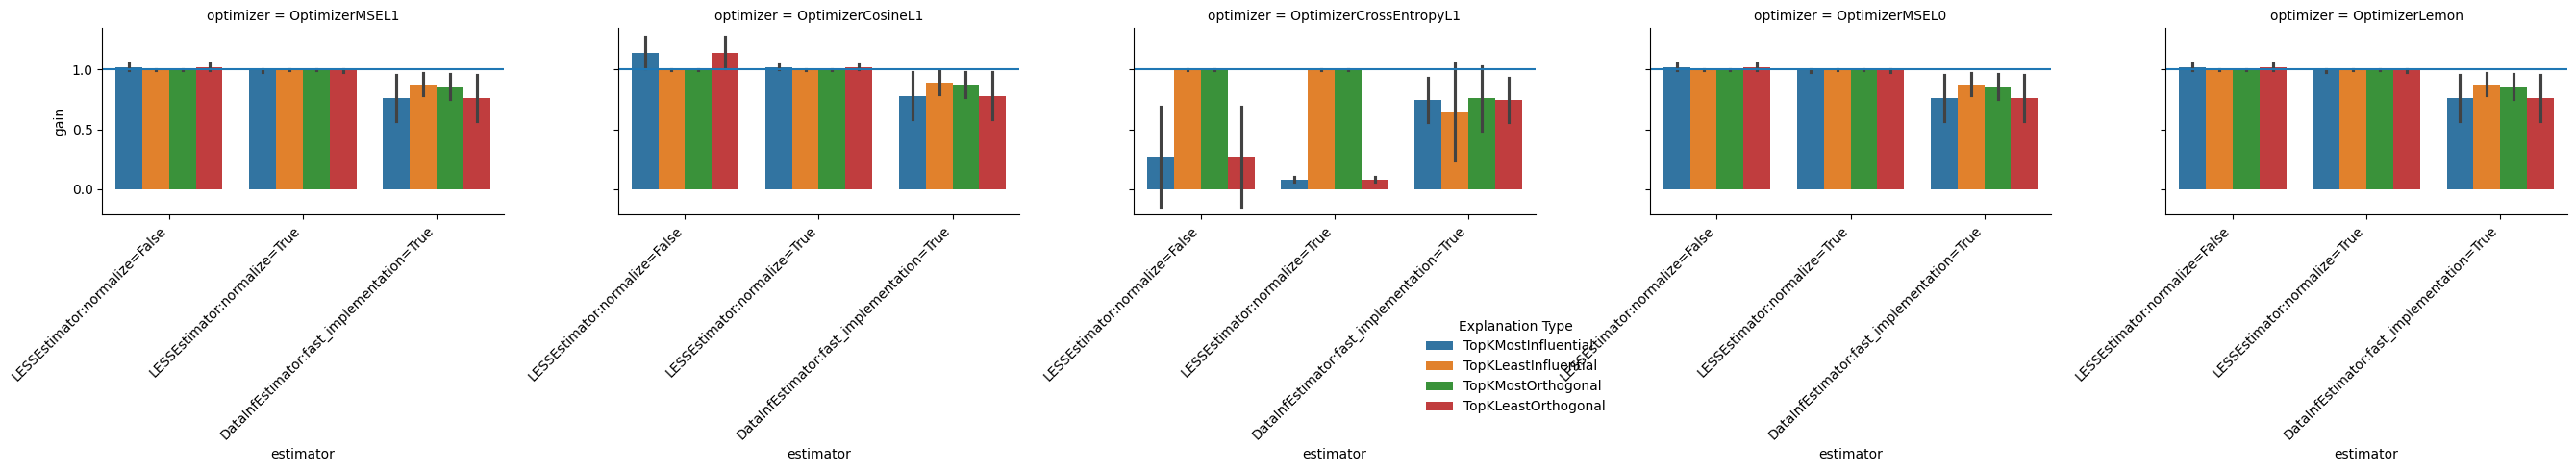

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df,
    x='estimator',
    y='gain',
    hue='explanation_type',  # side-by-side bars for each explanation_type
    kind='bar',
    col='optimizer',          # facet by optimizer
    ci='sd',
    col_wrap=5                # wrap facets if many optimizers
)

# Rotate x-axis labels for all facets
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.axhline(1)

sns.move_legend(g, "upper left", bbox_to_anchor=(.55, .35), title='Explanation Type')


plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

def dcg_score(relevance_scores):
    """Compute DCG given a list of relevance scores."""
    relevance_scores = np.array(relevance_scores)
    discounts = np.log2(np.arange(2, len(relevance_scores) + 2))
    return np.sum(relevance_scores / discounts)

def ndcg_score(true_relevance, pred_ranking):
    """Compute NDCG for a single sample."""
    # Map each item in pred_ranking to its true relevance score
    relevance = [true_relevance.get(item, 0) for item in pred_ranking]
    
    # DCG for predicted ranking
    dcg = dcg_score(relevance)
    
    # Ideal DCG by sorting true relevances descending
    ideal_relevance = sorted(true_relevance.values(), reverse=True)
    idcg = dcg_score(ideal_relevance)
    
    return dcg / idcg if idcg > 0 else 0

precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
ndcg_list = []
k_list = []

for k in [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400,len(experiment.train_dataset)]:
    full = estimators[0].influence_estimate.apply(lambda row: row.nlargest(k).index.tolist(), axis=1)
    coreset = estimators[1].influence_estimate.apply(lambda row: row.nlargest(k).index.tolist(), axis=1)

    for (_, val_a), (_, val_b) in zip(full.items(), coreset.items()):
        all_labels = list(set(val_a) | set(val_b))
        y_true = [1 if label in val_a else 0 for label in all_labels]
        y_pred = [1 if label in val_b else 0 for label in all_labels]

        precision_list.append(precision_score(y_true, y_pred, average='macro', zero_division=0))
        recall_list.append(recall_score(y_true, y_pred, average='macro', zero_division=0))
        f1_list.append(f1_score(y_true, y_pred, average='macro', zero_division=0))
        accuracy_list.append(accuracy_score(y_true, y_pred))

        # Prepare true relevance dict: relevant items get 1, others 0
        true_relevance = {label: 1 if label in val_a else 0 for label in all_labels}

        # Compute NDCG using val_b order and true_relevance
        ndcg_list.append(ndcg_score(true_relevance, val_b))

        k_list.append(k)

df = pd.DataFrame({
        'precision': precision_list,
        'recall': recall_list,
        'f1': f1_list,
        'accuracy': accuracy_list,
        'ndcg': ndcg_list,
        'k' : k_list
    }).groupby("k").mean()

df


In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(df['recall'], df['precision'], marker='o')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['precision'], marker='o', label='Precision')
plt.plot(df.index, df['recall'], marker='s', label='Recall')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Precision and Recall at k')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df.plot()

In [ ]:
df.plot()

In [ ]:
import numpy as np

def rowwise_recall(full: np.ndarray, coreset: np.ndarray) -> np.ndarray:
    k = full.shape[1]
    recall = np.array([
        len(set(f) & set(c)) / k
        for f, c in zip(full, coreset)
    ])
    return recall
recalls = rowwise_recall(full, coreset)
print("Average Recall:", recalls.mean())

In [ ]:
estimators[1].influence_estimate

In [ ]:
import itertools


In [ ]:
import numpy as np
from scipy import stats
import itertools
import pandas as pd




n_test = estimators[0].influence_estimate.shape[0]
pairwise_results = []
estimator_names = [est.get_config_string() for est in estimators]
for (i, est1), (j, est2) in itertools.combinations(enumerate(estimators), 2):
    corrs = []
    for t in range(n_test):
        corr = stats.spearmanr(est1.influence_estimate[t], est2.influence_estimate[t]).correlation
        corrs.append(corr)
    mean_corr = np.mean(corrs)
    pairwise_results.append({
        "Estimator a": est1.get_config_string(),
        "Estimator b": est2.get_config_string(),
        "Mean Spearman Corr": mean_corr
    })


results_df = pd.DataFrame(pairwise_results)
results_df


In [ ]:
matrix_df = pd.DataFrame(
    np.eye(len(estimators)),  # start with identity for diagonal = 1.0
    index=estimator_names,
    columns=estimator_names,
    dtype=float
)

for _, row in results_df.iterrows():
    a, b, corr = row["Estimator a"], row["Estimator b"], row["Mean Spearman Corr"]
    matrix_df.loc[a, b] = corr
    matrix_df.loc[b, a] = corr


plt.figure(figsize=(8, 6))
sns.heatmap(matrix_df, annot=True,  vmin=0, vmax=1, square=True)
plt.title("Mean Spearman Correlation Between Influence Estimators")
plt.tight_layout()
plt.show()

matrix_df


In [ ]:
estimator_less = estimators[0]
estimator_datainf = estimators[1]#DataInfEstimator(base_model_path, adapter_path, train_dataset, test_dataset,fast_implementation=True)
correlations = np.array([
    stats.spearmanr(estimator_datainf.influence_estimate[i], estimator_less.influence_estimate[i]).correlation for i in range(estimator_less.influence_estimate.shape[0])
])
df = pd.DataFrame({
    "Spearman Correlation": correlations,
    "Comparison": ["LESS vs DataInf"] * len(correlations)
})

# Plot using seaborn violinplot
plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x="Comparison", y="Spearman Correlation", inner="point")
plt.title("Spearman Correlation of Influence Estimates")
plt.ylim(-1.05, 1.05)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
estimator_less.influence_estimate

In [ ]:
estimator_datainf.influence_estimate